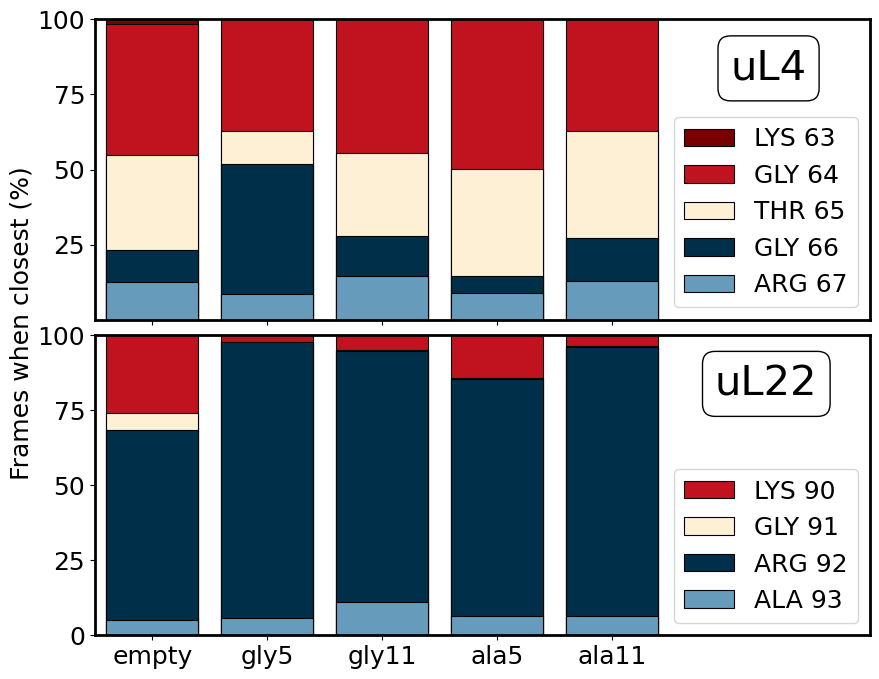

In [2]:
import matplotlib.pyplot as plt
import csv

plt.rcParams.update({'font.size': 18})

ALL_SYSTEMS = [
    "empty",
    "gly5",
    "gly11",
    "ala5",
    "ala11",
]
RESULTS = "../output_files/closest_atoms/"
COLOR_MAP = {
    "uL4": {
        "LYS 63": "#780000",
        "GLY 64": "#c1121f",
        "THR 65": "#fdf0d5",
        "GLY 66": "#003049",
        "ARG 67": "#669bbc",
    },
    "uL22": {
        "LYS 90": "#c1121f",
        "GLY 91": "#fdf0d5",
        "ARG 92": "#003049",
        "ALA 93": "#669bbc",
    }
}
XLIM = (-0.5, 6.25)
YLIM = (0, 100)

chains = ["uL4", "uL22"]
fig, axs = plt.subplots(len(chains), 1, figsize=(10, 8), sharex=True)
fig.text(0.04, 0.5, "Frames when closest (%)", va="center", rotation="vertical")
fig.subplots_adjust(hspace=0.05)
for j, chain in enumerate(chains):
    bars = []
    labels = []
    for i, system in enumerate(ALL_SYSTEMS):
        result_path = f"{RESULTS}/{system}.{chain}.dat"
        with open(result_path) as result_file:
            reader = csv.reader(result_file)
            # skip header
            next(reader)
            total_count = 0
            for row in reader:
                total_count += int(row[-1])
        with open(result_path) as result_file:
            reader = csv.reader(result_file)
            # skip header
            next(reader)
            height = 100
            data = []
            for row in reader:
                data.append((row[1], row[0] + " " + row[1], row[-1]))
            data = sorted(data)
            for _, residue, count in data:
                bar = axs[j].bar(
                    i,
                    height,
                    label=residue,
                    edgecolor="black",
                    linewidth=0.8,
                    color=COLOR_MAP[chain][residue]
                )
                height -= 100 * int(count) / total_count
                if residue not in labels:
                    bars.append(bar)
                    labels.append(residue)
    axs[j].legend(bars, labels, loc="lower right")
    axs[j].set_xticks(range(len(ALL_SYSTEMS)), labels=ALL_SYSTEMS)
    axs[j].set_ylim(YLIM)
    axs[j].set_xlim(XLIM)
    axs[j].spines[:].set_linewidth(2)

_ = axs[0].set_yticks([25, 50, 75, 100])
_ = axs[1].set_yticks([0, 25, 50, 75, 100])
_ = axs[0].text(
    XLIM[0]+0.82*(XLIM[1]-XLIM[0]),
    YLIM[0]+0.8*(YLIM[1]-YLIM[0]),
    chains[0],
    fontsize=30,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
)
_ = axs[1].text(
    XLIM[0]+0.8*(XLIM[1]-XLIM[0]),
    YLIM[0]+0.8*(YLIM[1]-YLIM[0]),
    chains[1],
    fontsize=30,
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
)